# UFO Data Analysis Project

### Linear Regression Implementation 


In [5]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

### Simple Linear Regression Class

In [6]:
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  
   
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

### Fit the Model and Visualize Results

Simple LR Coefficients: [1.06666667 1.00606061]
R² Score: 0.94


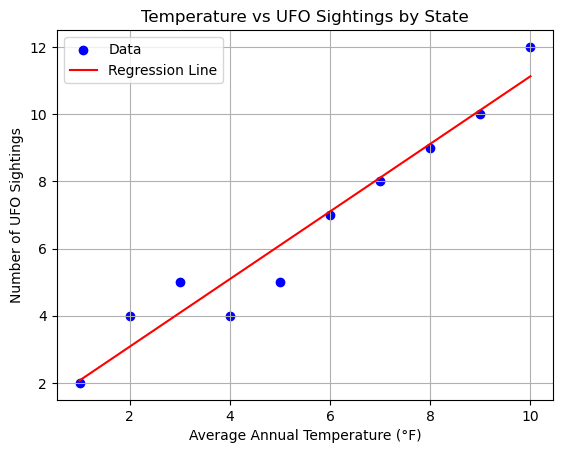

In [7]:
# populate temperature_data and num_sightings_data with actual data from the dataset

# For now, using dummy data

temperature_data = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
num_sightings_data = np.array([2,4,5,4,5,7,8,9,10,12])

slr = SimpleLinearRegression()
slr.fit(temperature_data, num_sightings_data)


print(f"Simple LR Coefficients: {slr.coefficients_}")
print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(temperature_data, num_sightings_data, color='blue', label='Data')
plt.plot(temperature_data, slr.y_pred_, color='red', label='Regression Line')
plt.title("Temperature vs UFO Sightings by State")
plt.xlabel("Average Annual Temperature (°F)")
plt.ylabel("Number of UFO Sightings")
plt.grid()
plt.legend()
plt.show()